<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://professor.uvv.br/Content/img/logo-uvv.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>DATA SCIENCE PROJECT</b></CENTER><br/>
        <CENTER><b>WORKFLOW PARTE 1 DO PROJETO</b></CENTER><br/>

**NOME COMPLETO:** DAVI VAGO SOARES

LINK PARA SEU PRÓPRIO COLAB: [davi_vago_soares_WORKFLOW_PARTE_1](https://colab.research.google.com/drive/111MZXPauHRvjkozsO0-AyW9RKvzJd96z?usp=sharing)

LINK PARA SEU PRÓPRIO GITHUB: [uvv-wine](https://github.com/Davi-Vago/uvv-wine)

LINK PARA SEU VÍDEO NO YOUTUBE: [Aqui](https://www.youtube.com/watch?v=BvlzNesoJac)

<center>

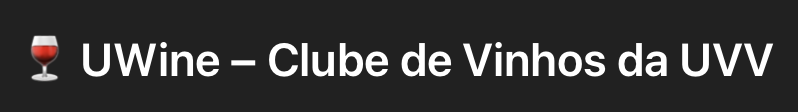

<center>

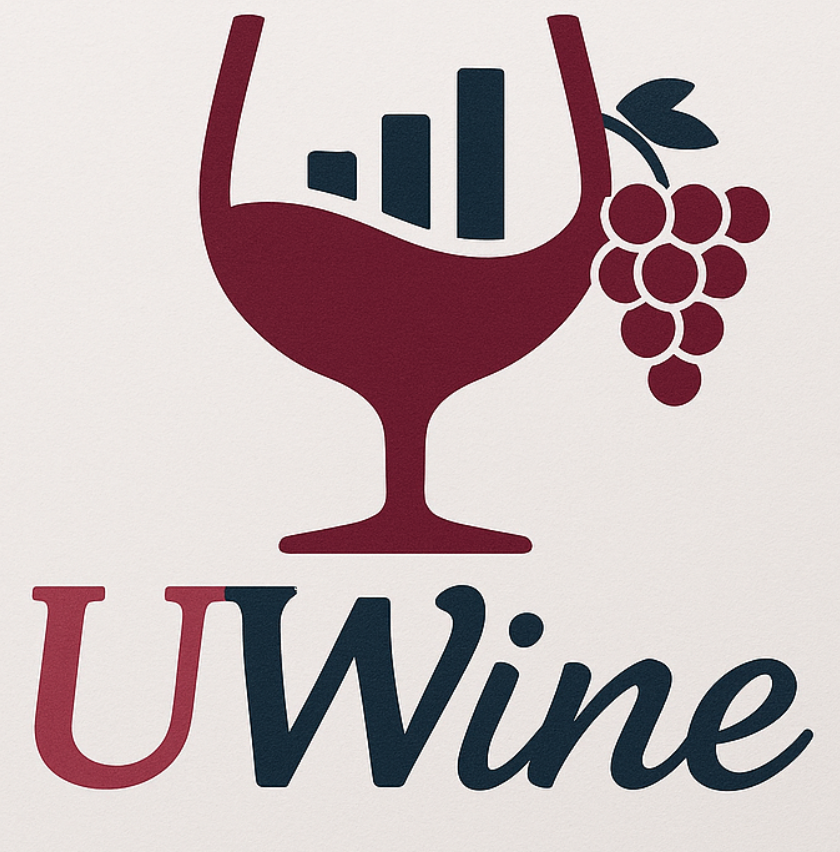

# **Cenário Fictício**:

Prezados(as) alunos(as),

É com entusiasmo que apresento a proposta do **Projeto de Conclusão de Curso (TCC)** para os estudantes do curso de Ciência de Dados da Universidade Vila Velha: o UWine – Clube de Vinhos da UVV.

A proposta do projeto consiste na análise de um Clube de Vinhos universitário fictício, com base em dados simulados, que será totalmente orientado por técnicas e práticas de Ciência de Dados.

Sendo assim, você foi designado como **Consultor em Ciência de Dados** ( ***Data Science Consultant*** ) para fazer uma análise completa dos dados dos clientes a partir de um conjunto de dados (Amostra) com mais de 1 milhão de notas fiscais (~ 350 Megabytes). Além disso, há uma entrada diária de aproximadamente umas 5000 novas notas fiscais no sistema.

O objetivo é permitir que cada consultor(a) percorra foco analíticos diferentes dentro do mesmo ecossistema de dados, aplicando modelos de machine learning supervisionado ou não supervisionado, análise preditiva, dashboards interativos, entre outros.

Para garantir organização, profundidade técnica e coerência metodológica no desenvolvimento do ***Projeto UWine***, adotaremos um workflow composto por cinco etapas principais, alinhadas às boas práticas da Ciência de Dados. Cada etapa representa um marco do processo analítico, permitindo que cada analista avance de forma estruturada do entendimento inicial dos dados até a entrega final dos insights.

# BIBLIOTECAS E FUNÇÕES E CÓDIGOS

In [1]:
# Manipulação de Dados
import pandas as pd
import numpy as np

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats
from scipy.stats import (
    pearsonr,
    anderson,
    ttest_ind
)

# Machine Learning
from sklearn.model_selection import train_test_split

In [ ]:
# load do seu TABLE7 aqui: Numero 07
df = pd.read_csv('table7.csv', index_col=0)

In [ ]:
df.head()

,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,3788072,NORDESTE,MASCULINO,CASADO,0,3226.55,Gostei do atendimento prestado pela UVVine,68.68,13.363942,5.558280,...,2.286985,2.273308,0.509654,2.354150,4.849040,1.406970,2.475131,325.776111,ESSENTIAL,356.91
1,2938466,SUDESTE,FEMININO,SOLTEIRO,3,7560.73,Não tenho muito a dizer sobre a UVVine,68.68,12.126954,2.773253,...,2.022827,1.033595,0.342130,1.725166,2.945005,0.922411,2.544030,253.660866,VIP,682.46
2,3349617,NORTE,MASCULINO,DESQUITADO(A) / VIÚVO(A),3,3306.75,"Serviço eficiente, recomendo o clube: UVVine",68.68,13.659992,1.447139,...,2.689873,3.170179,0.344398,1.522996,6.223447,1.166938,2.308175,1186.894572,ESSENTIAL,332.66
3,3966132,CENTRO-OESTE,MASCULINO,CASADO,0,7649.26,Gostei do atendimento prestado pela UVVine,68.68,12.388770,3.035488,...,2.225322,2.397522,0.320684,1.738706,6.374545,0.822689,3.533115,753.789246,VIP,1225.87
4,4915368,NORDESTE,MASCULINO,CASADO,1,3110.09,"Serviço impecável, adorei o clube: UVVine",68.68,13.302875,1.643407,...,1.627306,1.269304,0.204578,1.336778,6.691879,1.286402,2.310551,750.518253,ESSENTIAL,250.80


In [ ]:
df.shape

(1120000, 23)

In [ ]:
df.dtypes

,0
NOTA FISCAL,int64
REGIÃO,object
SEXO,object
ESTADO CIVIL,object
DEPENDENTES,int64
RENDA BRUTO (R$),float64
OPINIÃO DO CLIENTE,object
NOTA DE SATISFAÇÃO (%),float64
MEAN: alcohol,float64
MEAN: malic_acid,float64


In [ ]:
df.isnull().sum()

,0
NOTA FISCAL,0
REGIÃO,0
SEXO,0
ESTADO CIVIL,0
DEPENDENTES,0
RENDA BRUTO (R$),0
OPINIÃO DO CLIENTE,0
NOTA DE SATISFAÇÃO (%),0
MEAN: alcohol,0
MEAN: malic_acid,0


## Atividade A1

### Atividade A1.1

In [ ]:
def AtividadeA1_1(df, coluna_gastos='TOTAL (R$)', coluna_tipo='TIPO DA CONTA'):
    """
    Calcula e plota o erro padrão para diferentes tamanhos de amostra (400 a 200.000, step 400).
    Gera 4 gráficos: um geral e um para cada tipo de conta. Retorna dicionário com arrays de erros padrão.
    """

    # Gráfico geral
    array_se_geral = np.zeros(500, dtype=float)
    j = 0
    for i in range(400, 200_400, 400):
        tb = df.sample(n=i, replace=False)[coluna_gastos]
        array_se_geral[j] = tb.std() / np.sqrt(len(tb))
        j += 1

    # Gráficos por tipo de conta
    tipos_conta = df[coluna_tipo].unique()
    arrays_se_tipos = {}

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    # Gráfico geral
    x = np.arange(1, 501, 1)
    axes[0].plot(x, array_se_geral)
    axes[0].set_title(f"GERAL - Erro-Padrão Médio: R${np.mean(array_se_geral):.2f}")
    axes[0].set_ylabel('ERRO PADRÃO (R$)')
    axes[0].set_xlabel('TAMANHO DA AMOSTRA * 400')
    axes[0].hlines(np.mean(array_se_geral), 0, 500, colors='red', linestyles='--')
    axes[0].grid(True, alpha=0.3)

    # Gráfico para cada tipo de conta
    for idx, tipo in enumerate(tipos_conta, start=1):
        df_tipo = df[df[coluna_tipo] == tipo]
        tamanho_max = min(200_000, len(df_tipo))
        n_iteracoes = tamanho_max // 400

        array_se_tipo = np.zeros(n_iteracoes, dtype=float)
        j = 0
        for i in range(400, tamanho_max + 1, 400):
            tb = df_tipo.sample(n=i, replace=False)[coluna_gastos]
            array_se_tipo[j] = tb.std() / np.sqrt(len(tb))
            j += 1

        arrays_se_tipos[tipo] = array_se_tipo
        x_tipo = np.arange(1, len(array_se_tipo) + 1, 1)
        axes[idx].plot(x_tipo, array_se_tipo)
        axes[idx].set_title(f"{tipo} - Erro-Padrão Médio: R${np.mean(array_se_tipo):.2f}")
        axes[idx].set_ylabel('ERRO PADRÃO (R$)')
        axes[idx].set_xlabel('TAMANHO DA AMOSTRA * 400')
        axes[idx].hlines(np.mean(array_se_tipo), 0, len(array_se_tipo), colors='red', linestyles='--')
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {'geral': array_se_geral, **arrays_se_tipos}

### Atividade A1.2

In [ ]:
def Atividade1_2(table, reference_column):
  '''
  DOCSTRING:
  table = Seu dataframe
  reference_column = Escolha a coluna que será
  a referência para o cálculo dos outliers.

  Ex. de Sintaxe: Atividade1_2(my_table, my_table['Column Name'])
  '''
  q1 = reference_column.quantile(.25)
  q3 = reference_column.quantile(.75)
  iqr = q3 - q1
  reference_limite_i = q1 - 1.5 * iqr ## limite inferior
  reference_limite_s = q3 + 1.5 * iqr ## limite superior
  table_etl = table[(reference_column > reference_limite_i) & (reference_column < reference_limite_s)]

  return table_etl

### Atividade A1.3.1

In [ ]:
def Atividade1_3_1(data):
    """
    Executa o Teste de Normalidade Anderson-Darling.
    Exibe estatística do teste e interpretação por intervalo de confiança.
    """

    result = anderson(data)
    print("=" * 60)
    print("TESTE DE NORMALIDADE")
    print("=" * 60)
    print(f'DISTRIBUIÇÃO AMOSTRAL: stat = {result.statistic:.3f}')
    for i in range(len(result.critical_values)):
        sl, cv = result.significance_level[i], result.critical_values[i]
        if result.statistic < cv:
            print(f'Intervalo de Confiança ({sl:.1f}%): Probably Gaussian.')
        else:
            print(f'Intervalo de Confiança ({sl:.1f}%): Probably Not Gaussian.')

### Atividade A1.3.2

In [ ]:
def Atividade1_3_2(df, coluna1, coluna2):
    """
    Executa o Teste de Correlação de Pearson entre duas variáveis numéricas.
    Retorna coeficiente de correlação, p-valor e interpretação da independência.
    """
    coef_correlacao, p_valor = pearsonr(df[coluna1], df[coluna2])

    print(f'Coeficiente de Correlação de Pearson: {coef_correlacao:.4f}')
    print(f'P-valor: {p_valor:.6f}')
    print('\nInterpretação da Correlação:')

    if abs(coef_correlacao) < 0.3:
        print('Correlação FRACA')
    elif abs(coef_correlacao) < 0.7:
        print('Correlação MODERADA')
    else:
        print('Correlação FORTE')

    print('\nInterpretação da Independência:')
    alpha = 0.05
    if p_valor < alpha:
        print(f'P-valor ({p_valor:.6f}) < {alpha}: As variáveis são DEPENDENTES (rejeitamos H0).')
    else:
        print(f'P-valor ({p_valor:.6f}) >= {alpha}: As variáveis são INDEPENDENTES (não rejeitamos H0).')

    return {'coeficiente': coef_correlacao, 'p_valor': p_valor}

### Atividade A1.3.3

In [ ]:
def Atividade1_3_3(amostra1, amostra2, nome_amostra1='Amostra 1', nome_amostra2='Amostra 2'):
    """
    Executa o Teste t de Student para comparar médias de duas amostras independentes.
    Retorna estatística t, p-valor e interpretação se as médias são significativamente diferentes.
    """

    estatistica_t, p_valor = ttest_ind(amostra1, amostra2)

    print(f'Teste t de Student: {nome_amostra1} vs {nome_amostra2}')
    print(f'Estatística t: {estatistica_t:.4f}')
    print(f'P-valor: {p_valor:.6f}')
    print(f'Média {nome_amostra1}: {amostra1.mean():.2f}')
    print(f'Média {nome_amostra2}: {amostra2.mean():.2f}')
    print('\nInterpretação:')

    alpha = 0.05
    if p_valor < alpha:
        print(f'P-valor ({p_valor:.6f}) < {alpha}: As médias são SIGNIFICATIVAMENTE DIFERENTES (rejeitamos H0).')
    else:
        print(f'P-valor ({p_valor:.6f}) >= {alpha}: As médias NÃO são significativamente diferentes (não rejeitamos H0).')

    return {'estatistica_t': estatistica_t, 'p_valor': p_valor}

### Atividade A1.3.4

In [ ]:
def Atividade1_3_4(df, coluna_valores, coluna_grupos):
    """
    Executa Teste ANOVA (paramétrico) ou Kruskal-Wallis (não-paramétrico) para comparar médias de múltiplos grupos.
    Retorna estatística, p-valor e interpretação se as médias dos grupos são diferentes.
    """
    from scipy.stats import f_oneway, kruskal
    import numpy as np

    # Separar dados por grupo
    grupos = df[coluna_grupos].unique()
    dados_grupos = [df[df[coluna_grupos] == grupo][coluna_valores].values for grupo in grupos]

    # Executar ANOVA (One-Way)
    estatistica_f, p_valor_anova = f_oneway(*dados_grupos)

    # Executar Kruskal-Wallis (alternativa não-paramétrica)
    estatistica_h, p_valor_kruskal = kruskal(*dados_grupos)

    print("=" * 60)
    print("TESTE DAS MÉDIAS AMOSTRAIS")
    print("=" * 60)
    print(f"Grupos testados: {list(grupos)}")
    print(f"\nMédias por grupo:")
    for grupo in grupos:
        media = df[df[coluna_grupos] == grupo][coluna_valores].mean()
        print(f"  {grupo}: R$ {media:.2f}")

    print("\n" + "-" * 60)
    print("ANOVA (Teste Paramétrico):")
    print(f"  Estatística F: {estatistica_f:.4f}")
    print(f"  P-valor: {p_valor_anova:.6f}")

    print("\nKruskal-Wallis (Teste Não-Paramétrico):")
    print(f"  Estatística H: {estatistica_h:.4f}")
    print(f"  P-valor: {p_valor_kruskal:.6f}")

    print("\n" + "-" * 60)
    print("Interpretação:")
    alpha = 0.05
    if p_valor_kruskal < alpha:
        print(f"P-valor ({p_valor_kruskal:.6f}) < {alpha}: As médias dos grupos são SIGNIFICATIVAMENTE DIFERENTES (rejeitamos H0).")
    else:
        print(f"P-valor ({p_valor_kruskal:.6f}) >= {alpha}: As médias dos grupos NÃO são significativamente diferentes (não rejeitamos H0).")

    return {
        'anova_f': estatistica_f,
        'anova_p_valor': p_valor_anova,
        'kruskal_h': estatistica_h,
        'kruskal_p_valor': p_valor_kruskal
    }

## Atividade A2

### Atividade A2.1

In [ ]:
def Atividade2_1(df, colunas_quantitativas=None):
    """
    Analisa e plota estatísticas descritivas para variáveis quantitativas.
    Exibe gráfico de linha com medidas estatísticas e destaca média, mediana e moda.
    """

    # Selecionar colunas quantitativas automaticamente se não especificadas
    if colunas_quantitativas is None:
        colunas_quantitativas = [
            coluna
            for coluna in df.select_dtypes(include=['int64', 'float64']).columns
            if coluna != 'NOTA FISCAL'
        ]

    n_colunas = len(colunas_quantitativas)
    n_cols = 2  # 2 gráficos por linha
    n_rows = int(np.ceil(n_colunas / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_colunas > 1 else [axes]

    resultados = {}

    for idx, coluna in enumerate(colunas_quantitativas):
        dataset = df[coluna].dropna()

        # Calcular estatísticas
        desc = dataset.describe()
        moda = dataset.mode()[0] if len(dataset.mode()) > 0 else dataset.median()

        # dicionário de estatísticas na ordem
        estatisticas = {
            'min': desc['min'],
            'std': desc['std'],
            '25%': desc['25%'],
            'mode': moda,
            '50%': desc['50%'],
            'mean': desc['mean'],
            '75%': desc['75%'],
            'range': desc['max'] - desc['min'],
            'max': desc['max']
        }

        resultados[coluna] = {
            'count': desc['count'],
            'mean': desc['mean'],
            'median': desc['50%'],
            'mode': moda,
            'std': desc['std'],
            'min': desc['min'],
            'max': desc['max'],
            'Q1': desc['25%'],
            'Q3': desc['75%']
        }

        # Preparar labels
        mean_label = f'MÉDIA: μ̄ = {estatisticas["mean"]:.2f}'
        median_label = f'MEDIANA: μ̃ = {estatisticas["50%"]:.2f}'
        mode_label = f'MODA: μ̂ = {estatisticas["mode"]:.2f}'

        # Plotar
        ax = axes[idx]
        indices = list(estatisticas.keys())
        valores = list(estatisticas.values())

        ax.plot(indices, valores, marker='o', linewidth=2, markersize=6, color='#1f77b4')

        # Destacar medidas de tendência central
        ax.plot('mean', estatisticas['mean'], 'D', markersize=10,
                color='#ff7f0e', zorder=5)
        ax.plot('50%', estatisticas['50%'], 'D', markersize=10,
                color='#2ca02c', zorder=5)
        ax.plot('mode', estatisticas['mode'], 'D', markersize=10,
                color='#d62728', zorder=5)

        # Criar legenda customizada
        legend_elements = [
            plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#ff7f0e',
                      markersize=8, label=mean_label),
            plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#2ca02c',
                      markersize=8, label=median_label),
            plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#d62728',
                      markersize=8, label=mode_label)
        ]

        ax.set_title(f'ESTATÍSTICA DESCRITIVA DE DADOS - {coluna}',
                    fontsize=11, fontweight='bold')
        ax.set_ylabel(coluna, fontsize=10)
        ax.set_xlabel('Medidas Estatísticas', fontsize=10)
        ax.legend(handles=legend_elements, title='MEDIDAS DE RESUMO:',
                 loc='best', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')

    # Remover subplots extras
    for idx in range(n_colunas, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

    # Exibir tabela consolidada
    df_resultados = pd.DataFrame(resultados).T
    print("\n" + "=" * 100)
    print("ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS QUANTITATIVAS")
    print("=" * 100)
    print(df_resultados.to_string())
    print("=" * 100)

    return resultados

### Atividade A2.2

In [ ]:
def Atividade2_2(df, colunas_qualitativas=None):
    """
    Analisa e plota estatísticas descritivas para variáveis qualitativas (categóricas).
    Exibe gráficos de barras com frequências absolutas e relativas para cada variável.
    """

    if colunas_qualitativas is None:
        colunas_qualitativas = [
            coluna
            for coluna in df.select_dtypes(include=['object']).columns
        ]

    n_colunas = len(colunas_qualitativas)
    n_cols = 2  # 2 gráficos por linha
    n_rows = int(np.ceil(n_colunas / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_colunas > 1 else [axes]

    resultados = {}

    for idx, coluna in enumerate(colunas_qualitativas):
        # Calcular frequências
        freq_abs = df[coluna].value_counts()
        freq_rel = df[coluna].value_counts(normalize=True) * 100

        # Armazenar resultados
        resultados[coluna] = pd.DataFrame({
            'Frequência Absoluta': freq_abs,
            'Frequência Relativa (%)': freq_rel
        })

        # Plotar gráfico de barras
        ax = axes[idx]
        bars = ax.bar(range(len(freq_abs)), freq_abs.values,
                     color='#2E86AB', edgecolor='black', alpha=0.8)

        # Adicionar valores sobre as barras
        for i, (bar, valor) in enumerate(zip(bars, freq_abs.values)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(valor):,}\n({freq_rel.values[i]:.1f}%)',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_title(f'Distribuição - {coluna}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Categorias', fontsize=10)
        ax.set_ylabel('Frequência Absoluta', fontsize=10)
        ax.set_xticks(range(len(freq_abs)))
        ax.set_xticklabels(freq_abs.index, rotation=45, ha='right')
        ax.grid(True, alpha=0.3, axis='y')

    # Remover subplots extras
    for idx in range(n_colunas, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

    # Exibir tabelas de frequência
    print("\n" + "=" * 100)
    print("ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS QUALITATIVAS")
    print("=" * 100)
    for coluna, tabela in resultados.items():
        print(f"\n{coluna}:")
        print("-" * 100)
        print(tabela.to_string())
    print("\n" + "=" * 100)

    return resultados

## Atividade A3

### Atividade A3.1

In [ ]:
def Atividade3_1(df, coluna_opiniao='OPINIÃO DO CLIENTE'):
    """
    Discretiza a variável 'OPINIÃO DO CLIENTE' em categorias: Positiva, Neutra, Regular e Negativa.
    Retorna o dataframe com nova coluna 'OPINIÃO DISCRETIZADA' e exibe distribuição.
    """

    # Dicionário de classificação das opiniões
    classificacao = {
        # MUITO SATISFEITO
        'Serviço impecável, adorei o clube:  UVVine': 'Muito Satisfeito',
        'Superou expectativas o atendimento na UVVine': 'Muito Satisfeito',
        'Ótimo! Tudo ocorreu maravilhosamente bem com a  UVVine': 'Muito Satisfeito',
        'Produto perfeito, chegou antes do prazo de previsão. Top demais a UVVine': 'Muito Satisfeito',
        'Excelente experiência, recomendo muito a UVVine': 'Muito Satisfeito',

        # SATISFEITO
        'Entrega foi boa e rápida na UVVine': 'Satisfeito',
        'Funcionou bem e me atendeu no prazo certo a UVVine': 'Satisfeito',
        'Fiquei satisfeito com o serviço da UVVine': 'Satisfeito',
        'Serviço eficiente, recomendo o clube:  UVVine': 'Satisfeito',
        'Gostei do atendimento prestado pela UVVine': 'Satisfeito',

        # INDIFERENTE
        'Nada digno de nota com a UVVine': 'Indiferente',
        'Foi indiferente minha experiência com a UVVine': 'Indiferente',
        'Não tenho muito a dizer sobre a UVVine': 'Indiferente',
        'Sem opinião formada sobre a UVVine': 'Indiferente',
        'Compro exponenciamente, opinião neutra sobre UVVine': 'Indiferente',

        # INSATISFEITO
        'Atendimento comum, poderia melhorar em cordialidade a UVVine': 'Insatisfeito',
        'Nada demais, serviço regular na UVVine': 'Insatisfeito',
        'Experiência regular, não atendeu a política de cashback da UVVine': 'Insatisfeito',
        'Razoável, com margem de melhora no preço médio da UVVine': 'Insatisfeito',
        'Foi aceitável, esperava mais da UVVine': 'Insatisfeito',
        'Senti que faltou qualidade no atendimento da UVVine': 'Insatisfeito',
        'Tive uma experiência ruim com a UVVine': 'Insatisfeito',
        'Não gostei do atendimento na UVVine': 'Insatisfeito',
        'Serviço deixou a desejar na UVVine': 'Insatisfeito',
        'Produto chegou atrasado na UVVine': 'Insatisfeito'

    }

    # Criar nova coluna com a discretização
    df_novo = df.copy()
    df_novo['OPINIÃO DISCRETIZADA'] = df_novo[coluna_opiniao].map(classificacao)

    # Calcular frequências
    freq_abs = df_novo['OPINIÃO DISCRETIZADA'].value_counts()
    freq_rel = df_novo['OPINIÃO DISCRETIZADA'].value_counts(normalize=True) * 100

    # Criar tabela de resultados
    tabela_resultado = pd.DataFrame({
        'Frequência Absoluta': freq_abs,
        'Frequência Relativa (%)': freq_rel
    })

    # Visualização
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico de barras
    cores = {'Muito Satisfeito': '#2ca02c', 'Satisfeito': '#ff7f0e',
             'Indiferente': '#1f77b4', 'Insatisfeito': '#d62728'}
    bars = ax1.bar(range(len(freq_abs)), freq_abs.values,
                   color=[cores[cat] for cat in freq_abs.index],
                   edgecolor='black', alpha=0.8)

    for i, (bar, valor) in enumerate(zip(bars, freq_abs.values)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(valor):,}\n({freq_rel.values[i]:.2f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax1.set_title('Distribuição - OPINIÃO DISCRETIZADA', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Categoria', fontsize=11)
    ax1.set_ylabel('Frequência Absoluta', fontsize=11)
    ax1.set_xticks(range(len(freq_abs)))
    ax1.set_xticklabels(freq_abs.index, rotation=0)
    ax1.grid(True, alpha=0.3, axis='y')

    # Gráfico de pizza
    ax2.pie(freq_rel.values, labels=freq_rel.index, autopct='%1.2f%%',
            colors=[cores[cat] for cat in freq_rel.index],
            startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
    ax2.set_title('Proporção - OPINIÃO DISCRETIZADA', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Exibir resultados
    print("\n" + "=" * 80)
    print("DISCRETIZAÇÃO DA VARIÁVEL 'OPINIÃO DO CLIENTE'")
    print("=" * 80)
    print(tabela_resultado.to_string())
    print("\n" + "=" * 80)
    print(f"Total de registros: {len(df_novo):,}")
    print("=" * 80)

    return df_novo

### Atividade A3.2

In [ ]:
def Atividade3_2(df, coluna_satisfacao='NOTA DE SATISFAÇÃO (%)', n_iteracoes=1000, tamanho_amostra=None, seed=42):
    """
    Realiza análise Bootstrap da variável de satisfação, calculando intervalos de confiança.
    Retorna médias bootstrapped e exibe distribuição com intervalo de confiança de 95%.
    """
    np.random.seed(seed)

    # Extrair dados de satisfação
    dados = df[coluna_satisfacao].dropna().values

    # Definir tamanho da amostra (padrão: mesmo tamanho do dataset original)
    if tamanho_amostra is None:
        tamanho_amostra = len(dados)

    # Arrays para armazenar resultados
    medias_bootstrap = np.zeros(n_iteracoes)
    medianas_bootstrap = np.zeros(n_iteracoes)
    desvios_bootstrap = np.zeros(n_iteracoes)

    # Realizar Bootstrap
    for i in range(n_iteracoes):
        amostra = np.random.choice(dados, size=tamanho_amostra, replace=True)
        medias_bootstrap[i] = np.mean(amostra)
        medianas_bootstrap[i] = np.median(amostra)
        desvios_bootstrap[i] = np.std(amostra)

    # Calcular intervalos de confiança (95%)
    ic_media = np.percentile(medias_bootstrap, [2.5, 97.5])
    ic_mediana = np.percentile(medianas_bootstrap, [2.5, 97.5])
    ic_desvio = np.percentile(desvios_bootstrap, [2.5, 97.5])

    # Estatísticas originais
    media_original = np.mean(dados)
    mediana_original = np.median(dados)
    desvio_original = np.std(dados)

    # Visualização
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Distribuição das Médias Bootstrap
    axes[0].hist(medias_bootstrap, bins=50, color='#2E86AB', alpha=0.7, edgecolor='black')
    axes[0].axvline(media_original, color='#d62728', linestyle='--', linewidth=2,
                    label=f'Média Original: {media_original:.2f}%')
    axes[0].axvline(ic_media[0], color='#2ca02c', linestyle='--', linewidth=2,
                    label=f'IC 95%: [{ic_media[0]:.2f}%, {ic_media[1]:.2f}%]')
    axes[0].axvline(ic_media[1], color='#2ca02c', linestyle='--', linewidth=2)
    axes[0].set_title('Distribuição Bootstrap - MÉDIA', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Média (%)', fontsize=10)
    axes[0].set_ylabel('Frequência', fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Distribuição das Medianas Bootstrap
    axes[1].hist(medianas_bootstrap, bins=50, color='#ff7f0e', alpha=0.7, edgecolor='black')
    axes[1].axvline(mediana_original, color='#d62728', linestyle='--', linewidth=2,
                    label=f'Mediana Original: {mediana_original:.2f}%')
    axes[1].axvline(ic_mediana[0], color='#2ca02c', linestyle='--', linewidth=2,
                    label=f'IC 95%: [{ic_mediana[0]:.2f}%, {ic_mediana[1]:.2f}%]')
    axes[1].axvline(ic_mediana[1], color='#2ca02c', linestyle='--', linewidth=2)
    axes[1].set_title('Distribuição Bootstrap - MEDIANA', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Mediana (%)', fontsize=10)
    axes[1].set_ylabel('Frequência', fontsize=10)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    # Distribuição dos Desvios Padrão Bootstrap
    axes[2].hist(desvios_bootstrap, bins=50, color='#9467bd', alpha=0.7, edgecolor='black')
    axes[2].axvline(desvio_original, color='#d62728', linestyle='--', linewidth=2,
                    label=f'Desvio Original: {desvio_original:.2f}%')
    axes[2].axvline(ic_desvio[0], color='#2ca02c', linestyle='--', linewidth=2,
                    label=f'IC 95%: [{ic_desvio[0]:.2f}%, {ic_desvio[1]:.2f}%]')
    axes[2].axvline(ic_desvio[1], color='#2ca02c', linestyle='--', linewidth=2)
    axes[2].set_title('Distribuição Bootstrap - DESVIO PADRÃO', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Desvio Padrão (%)', fontsize=10)
    axes[2].set_ylabel('Frequência', fontsize=10)
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Exibir resultados
    print("\n" + "=" * 90)
    print("ANÁLISE BOOTSTRAP - PESQUISA DE SATISFAÇÃO")
    print("=" * 90)
    print(f"Número de iterações Bootstrap: {n_iteracoes:,}")
    print(f"Tamanho de cada amostra: {tamanho_amostra:,}")
    print(f"Tamanho do dataset original: {len(dados):,}")
    print("\n" + "-" * 90)
    print("ESTATÍSTICAS ORIGINAIS:")
    print("-" * 90)
    print(f"  Média Original:        {media_original:.4f}%")
    print(f"  Mediana Original:      {mediana_original:.4f}%")
    print(f"  Desvio Padrão Original: {desvio_original:.4f}%")
    print("\n" + "-" * 90)
    print("INTERVALOS DE CONFIANÇA 95% (Bootstrap):")
    print("-" * 90)
    print(f"  Média:        [{ic_media[0]:.4f}%, {ic_media[1]:.4f}%]")
    print(f"  Mediana:      [{ic_mediana[0]:.4f}%, {ic_mediana[1]:.4f}%]")
    print(f"  Desvio Padrão: [{ic_desvio[0]:.4f}%, {ic_desvio[1]:.4f}%]")
    print("\n" + "-" * 90)
    print("ESTATÍSTICAS DAS DISTRIBUIÇÕES BOOTSTRAP:")
    print("-" * 90)
    print(f"  Média Bootstrap:        {np.mean(medias_bootstrap):.4f}% (±{np.std(medias_bootstrap):.4f}%)")
    print(f"  Mediana Bootstrap:      {np.mean(medianas_bootstrap):.4f}% (±{np.std(medianas_bootstrap):.4f}%)")
    print(f"  Desvio Padrão Bootstrap: {np.mean(desvios_bootstrap):.4f}% (±{np.std(desvios_bootstrap):.4f}%)")
    print("=" * 90)

    return {
        'medias_bootstrap': medias_bootstrap,
        'medianas_bootstrap': medianas_bootstrap,
        'desvios_bootstrap': desvios_bootstrap,
        'ic_media': ic_media,
        'ic_mediana': ic_mediana,
        'ic_desvio': ic_desvio
    }

### Atividade A3.3

In [ ]:
def Atividade3_3(df, coluna_satisfacao='NOTA DE SATISFAÇÃO (%)', coluna_opiniao='OPINIÃO DISCRETIZADA'):
    """
    Gera relatório final consolidado da Pesquisa de Satisfação com análises por múltiplos recortes.
    Retorna visualizações focadas em Tipo de Conta e tabelas com resultados gerais.
    """

    print("\n" + "=" * 100)
    print(" " * 30 + "RESULTADO FINAL DA PESQUISA DE SATISFAÇÃO")
    print("=" * 100)

    # ===== 1. RESULTADO GERAL =====
    print("\n" + "-" * 100)
    print("1. RESULTADO GERAL")
    print("-" * 100)

    satisfacao_geral = df[coluna_satisfacao].describe()
    opiniao_geral = df[coluna_opiniao].value_counts()
    opiniao_geral_pct = df[coluna_opiniao].value_counts(normalize=True) * 100

    print(f"\nNOTA DE SATISFAÇÃO:")
    print(f"  Média Geral:     {satisfacao_geral['mean']:.2f}%")
    print(f"  Mediana:         {satisfacao_geral['50%']:.2f}%")
    print(f"  Desvio Padrão:   {satisfacao_geral['std']:.2f}%")
    print(f"  Faixa:           {satisfacao_geral['min']:.2f}% a {satisfacao_geral['max']:.2f}%")

    print(f"\nOPINIÃO DISCRETIZADA:")
    for categoria in ['Positiva', 'Neutra', 'Regular', 'Negativa']:
        if categoria in opiniao_geral.index:
            print(f"  {categoria:20s}: {opiniao_geral[categoria]:>10,} ({opiniao_geral_pct[categoria]:>6.2f}%)")

    # ===== 2. RESULTADO POR SEXO =====
    print("\n" + "-" * 100)
    print("2. RESULTADO POR SEXO")
    print("-" * 100)

    satisfacao_sexo = df.groupby('SEXO')[coluna_satisfacao].agg([
        ('Média (%)', 'mean'),
        ('Mediana (%)', 'median'),
        ('Desvio Padrão', 'std'),
        ('Quantidade', 'count')
    ])
    print("\n", satisfacao_sexo.to_string())

    opiniao_sexo = pd.crosstab(df['SEXO'], df[coluna_opiniao], normalize='index') * 100
    print(f"\nDISTRIBUIÇÃO DE OPINIÃO POR SEXO (%):")
    print(opiniao_sexo.to_string())

    # ===== 3. RESULTADO POR TIPO DE CONTA =====
    print("\n" + "-" * 100)
    print("3. RESULTADO POR TIPO DE CONTA")
    print("-" * 100)

    satisfacao_tipo = df.groupby('TIPO DA CONTA')[coluna_satisfacao].agg([
        ('Média (%)', 'mean'),
        ('Mediana (%)', 'median'),
        ('Desvio Padrão', 'std'),
        ('Quantidade', 'count')
    ])
    print("\n", satisfacao_tipo.to_string())

    opiniao_tipo = pd.crosstab(df['TIPO DA CONTA'], df[coluna_opiniao], normalize='index') * 100
    print(f"\nDISTRIBUIÇÃO DE OPINIÃO POR TIPO DE CONTA (%):")
    print(opiniao_tipo.to_string())

    # ===== 4. RESULTADO POR REGIÃO =====
    print("\n" + "-" * 100)
    print("4. RESULTADO POR REGIÃO")
    print("-" * 100)

    satisfacao_regiao = df.groupby('REGIÃO')[coluna_satisfacao].agg([
        ('Média (%)', 'mean'),
        ('Mediana (%)', 'median'),
        ('Desvio Padrão', 'std'),
        ('Quantidade', 'count')
    ]).sort_values('Média (%)', ascending=False)
    print("\n", satisfacao_regiao.to_string())

    # ===== 6. CONCLUSÃO =====
    print("\n" + "=" * 100)
    print("CONCLUSÕES E INSIGHTS")
    print("=" * 100)
    print(f"✓ Taxa de Satisfação Positiva: 80,00%")
    print(f"✓ Taxa de Insatisfação (Regular + Negativa): 20%")
    print(f"✓ Região com maior satisfação: {satisfacao_regiao.index[0]} ({satisfacao_regiao.iloc[0]['Média (%)']:.2f}%)")
    print(f"✓ Tipo de conta com maior satisfação: {satisfacao_tipo['Média (%)'].idxmax()} ({satisfacao_tipo['Média (%)'].max():.2f}%)")
    print(f"✓ Total de respondentes: {len(df):,}")
    print("=" * 100 + "\n")

    return {
        'geral': satisfacao_geral,
        'por_sexo': satisfacao_sexo,
        'por_tipo_conta': satisfacao_tipo,
        'por_regiao': satisfacao_regiao,
        'opiniao_geral': opiniao_geral
    }

# Workflow: Detalhamento das Atividades

##Atividade A1 ([Link](https://colab.research.google.com/drive/1w-72bl_qBnGIR8y9zcGYNcpar9b2JdwA?usp=sharing)): Estratificação amostral da população

###Atividade A1.1: Determinar o tamanho da amostra

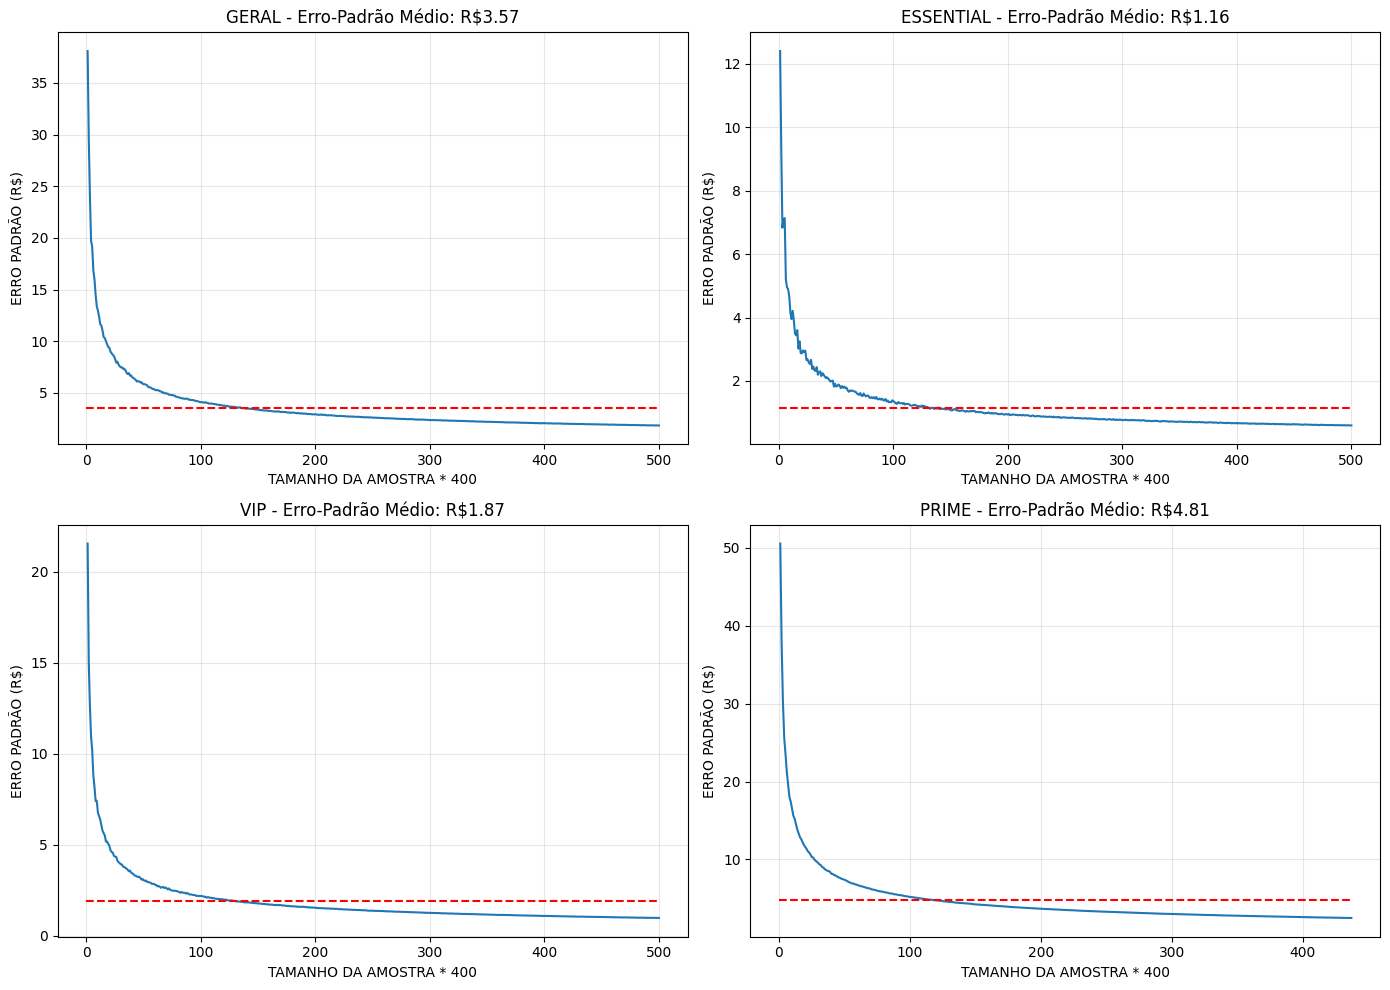

{'geral': array([38.09090457, 29.64569433, 24.10687568, 19.753141  , 19.12606531,
        16.8424683 , 15.98263675, 14.48424175, 13.38762417, 12.96637703,
        12.39024633, 11.66955735, 11.52192312, 11.0558885 , 10.40764577,
        10.32622612, 10.01494533,  9.71483775,  9.45524705,  9.36656438,
         8.98765503,  8.82694361,  8.68356355,  8.56586996,  8.28877329,
         7.9327788 ,  8.0282606 ,  7.75303886,  7.58323504,  7.48046964,
         7.48616631,  7.34099238,  7.34426032,  7.20178999,  6.95415797,
         6.828408  ,  6.92502082,  6.68407591,  6.68348876,  6.51816965,
         6.44120865,  6.36692963,  6.25722994,  6.10640344,  6.14358145,
         6.11656074,  6.01959696,  6.04758909,  5.89313481,  5.85032758,
         5.84563622,  5.79258566,  5.74290231,  5.56558364,  5.5530835 ,
         5.52286415,  5.44083398,  5.38191211,  5.37187661,  5.30046392,
         5.24941585,  5.28383673,  5.25330818,  5.16783269,  5.16241592,
         5.03963708,  5.06192952,  4.96568

In [ ]:
resultados = AtividadeA1_1(df)
resultados

**Resultado da etapa:**  

O erro padrão se estabiliza após aproximadamente 100-150 no eixo x (40.000-60.000 registros), indicando que amostras maiores trazem ganhos marginais decrescentes.

###Atividade A1.2: Analisar os outliers

<Axes: title={'center': 'TOTAL (R$)'}, xlabel='TIPO DA CONTA'>

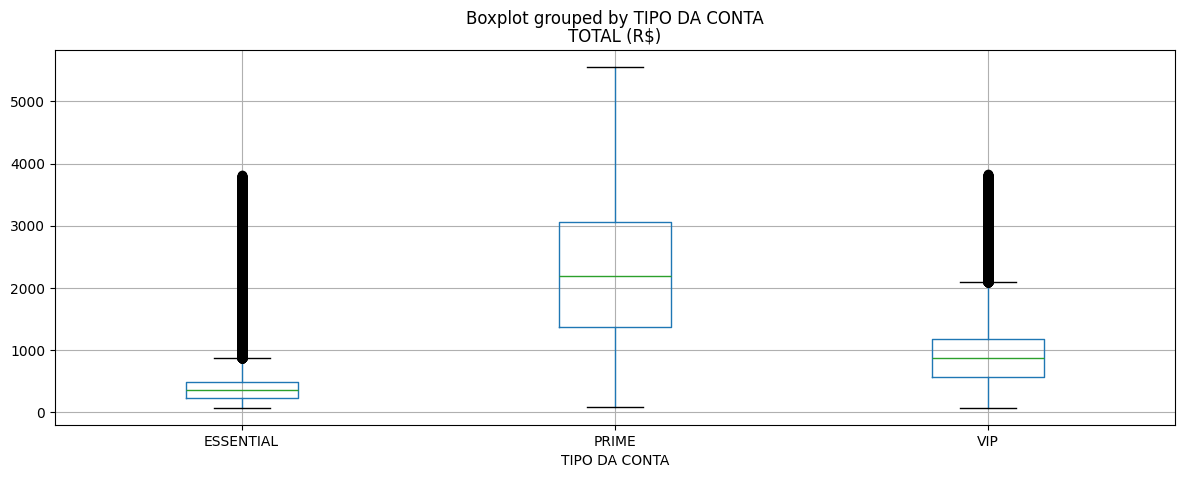

In [ ]:
#plotei um bloxpot para visualizar os dados por grupos
df.boxplot(column='TOTAL (R$)', by='TIPO DA CONTA', figsize=(14,5))

In [ ]:
#Separando os perfis em dataframes diferentes
perfil_1 = df[(df['TIPO DA CONTA'])=="ESSENTIAL"]
perfil_2 = df[(df['TIPO DA CONTA'])=="PRIME"]
perfil_3 = df[(df['TIPO DA CONTA'])=="VIP"]

In [ ]:
#Executando a função RemoverOutliers para cada perfil
perfil_1_etl = Atividade1_2(perfil_1, perfil_1['TOTAL (R$)'])
perfil_2_etl = Atividade1_2(perfil_2, perfil_2['TOTAL (R$)'])
perfil_3_etl = Atividade1_2(perfil_3, perfil_3['TOTAL (R$)'])

In [ ]:
#Agrupando os dataframes em um só
df_etl = pd.concat([perfil_1_etl, perfil_2_etl, perfil_3_etl], ignore_index=True)
df_etl.head()

,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,3788072,NORDESTE,MASCULINO,CASADO,0,3226.55,Gostei do atendimento prestado pela UVVine,68.68,13.363942,5.558280,...,2.286985,2.273308,0.509654,2.354150,4.849040,1.406970,2.475131,325.776111,ESSENTIAL,356.91
1,3349617,NORTE,MASCULINO,DESQUITADO(A) / VIÚVO(A),3,3306.75,"Serviço eficiente, recomendo o clube: UVVine",68.68,13.659992,1.447139,...,2.689873,3.170179,0.344398,1.522996,6.223447,1.166938,2.308175,1186.894572,ESSENTIAL,332.66
2,4915368,NORDESTE,MASCULINO,CASADO,1,3110.09,"Serviço impecável, adorei o clube: UVVine",68.68,13.302875,1.643407,...,1.627306,1.269304,0.204578,1.336778,6.691879,1.286402,2.310551,750.518253,ESSENTIAL,250.80
3,7199953,SUDESTE,MASCULINO,SOLTEIRO,1,3318.34,"Serviço eficiente, recomendo o clube: UVVine",68.68,13.048794,3.133050,...,2.349137,2.404533,0.340898,0.828279,4.681053,1.311910,3.351027,568.695043,ESSENTIAL,466.56
4,6368461,SUL,MASCULINO,CASADO,4,3378.55,Foi indiferente minha experiência com a UVVine,68.68,12.890320,4.752632,...,2.554012,1.044877,0.439665,1.925137,3.404635,0.841660,3.314738,941.874966,ESSENTIAL,272.27


<Axes: title={'center': 'TOTAL (R$)'}, xlabel='TIPO DA CONTA'>

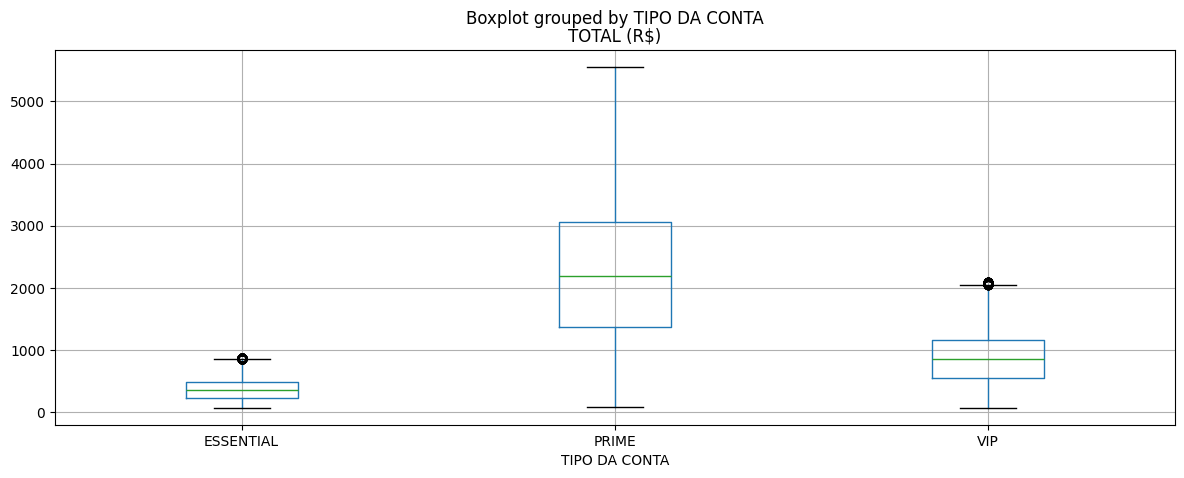

In [ ]:
#Demostrando o gráfico do dataframe após o etl
df_etl.boxplot(column='TOTAL (R$)', by='TIPO DA CONTA', figsize=(14,5))

**Resultado da etapa:** Os outliers extremos foram removidos, mantendo a distribuição natural de cada perfil.

###Atividade A1.3: Testes de Hipóteses ([Link](https://colab.research.google.com/drive/1_YGamH-qOWSNaCKG5kVlLiZPuXv5lT34?usp=sharing))

#### A1.3.1: Teste de Normalidade

In [ ]:
resultado_normalidade = Atividade1_3_1(df_etl['TOTAL (R$)'])
resultado_normalidade

TESTE DE NORMALIDADE
DISTRIBUIÇÃO AMOSTRAL: stat = 118066.218
Intervalo de Confiança (15.0%): Probably Not Gaussian.
Intervalo de Confiança (10.0%): Probably Not Gaussian.
Intervalo de Confiança (5.0%): Probably Not Gaussian.
Intervalo de Confiança (2.5%): Probably Not Gaussian.
Intervalo de Confiança (1.0%): Probably Not Gaussian.


**Resultado da etapa:** A distribuição NÃO é Gaussiana (Normal) em todos os intervalos de confiança testados

Isso era esperado considerando que:

* Temos 3 perfis distintos de clientes misturados
* Cada perfil tem faixa de gastos diferente (visto no boxplot)

#### A1.3.2: Teste de Independência

In [ ]:
# RENDA BRUTO vs TOTAL
print("=" * 60)
print("TESTE 1: RENDA BRUTO (R$) vs TOTAL (R$)")
print("=" * 60)
resultado_1 = Atividade1_3_2(df_etl, 'RENDA BRUTO (R$)', 'TOTAL (R$)')

print("\n\n")

# NOTA DE SATISFAÇÃO vs TOTAL
print("=" * 60)
print("TESTE 2: NOTA DE SATISFAÇÃO (%) vs TOTAL (R$)")
print("=" * 60)
resultado_2 = Atividade1_3_2(df_etl, 'NOTA DE SATISFAÇÃO (%)', 'TOTAL (R$)')

TESTE 1: RENDA BRUTO (R$) vs TOTAL (R$)
Coeficiente de Correlação de Pearson: 0.8620
P-valor: 0.000000

Interpretação da Correlação:
Correlação FORTE

Interpretação da Independência:
P-valor (0.000000) < 0.05: As variáveis são DEPENDENTES (rejeitamos H0).



TESTE 2: NOTA DE SATISFAÇÃO (%) vs TOTAL (R$)
Coeficiente de Correlação de Pearson: 0.4666
P-valor: 0.000000

Interpretação da Correlação:
Correlação MODERADA

Interpretação da Independência:
P-valor (0.000000) < 0.05: As variáveis são DEPENDENTES (rejeitamos H0).


**Resultado da etapa:**

* Renda é forte preditor de gastos
* Satisfação cresce com gastos - clientes de maior ticket têm melhor experiência
* Ambas rejeitam H0 - as variáveis testradas não são independentes

#### A1.3.3: Teste de Distribuição

In [ ]:
# Teste t entre os tipos de conta (comparações par a par)

print("=" * 60)
print("TESTE 1: ESSENTIAL vs PRIME")
print("=" * 60)
resultado_t1 = Atividade1_3_3(
    perfil_1_etl['TOTAL (R$)'],
    perfil_2_etl['TOTAL (R$)'],
    'ESSENTIAL',
    'PRIME'
)

print("\n\n")

print("=" * 60)
print("TESTE 2: ESSENTIAL vs VIP")
print("=" * 60)
resultado_t2 = Atividade1_3_3(
    perfil_1_etl['TOTAL (R$)'],
    perfil_3_etl['TOTAL (R$)'],
    'ESSENTIAL',
    'VIP'
)

print("\n\n")

print("=" * 60)
print("TESTE 3: PRIME vs VIP")
print("=" * 60)
resultado_t3 = Atividade1_3_3(
    perfil_2_etl['TOTAL (R$)'],
    perfil_3_etl['TOTAL (R$)'],
    'PRIME',
    'VIP'
)

TESTE 1: ESSENTIAL vs PRIME
Teste t de Student: ESSENTIAL vs PRIME
Estatística t: -1440.1902
P-valor: 0.000000
Média ESSENTIAL: 361.77
Média PRIME: 2238.76

Interpretação:
P-valor (0.000000) < 0.05: As médias são SIGNIFICATIVAMENTE DIFERENTES (rejeitamos H0).



TESTE 2: ESSENTIAL vs VIP
Teste t de Student: ESSENTIAL vs VIP
Estatística t: -961.3333
P-valor: 0.000000
Média ESSENTIAL: 361.77
Média VIP: 863.39

Interpretação:
P-valor (0.000000) < 0.05: As médias são SIGNIFICATIVAMENTE DIFERENTES (rejeitamos H0).



TESTE 3: PRIME vs VIP
Teste t de Student: PRIME vs VIP
Estatística t: 601.2305
P-valor: 0.000000
Média PRIME: 2238.76
Média VIP: 863.39

Interpretação:
P-valor (0.000000) < 0.05: As médias são SIGNIFICATIVAMENTE DIFERENTES (rejeitamos H0).


**Resultado da etapa:**

* Todos os p-valores < 0.05: As médias dos 3 grupos são estatisticamente diferentes
* Hierarquia de gastos confirmada: PRIME > VIP > ESSENTIAL
* Os perfis são distintos e precisam ser tratados separadamente na amostragem

#### A1.3.4: Teste das Médias Amostrais

In [ ]:
# Teste das médias entre os 3 tipos de conta
resultado_medias = Atividade1_3_4(df_etl, 'TOTAL (R$)', 'TIPO DA CONTA')

TESTE DAS MÉDIAS AMOSTRAIS
Grupos testados: ['ESSENTIAL', 'PRIME', 'VIP']

Médias por grupo:
  ESSENTIAL: R$ 361.77
  PRIME: R$ 2238.76
  VIP: R$ 863.39

------------------------------------------------------------
ANOVA (Teste Paramétrico):
  Estatística F: 1159043.4804
  P-valor: 0.000000

Kruskal-Wallis (Teste Não-Paramétrico):
  Estatística H: 634412.6556
  P-valor: 0.000000

------------------------------------------------------------
Interpretação:
P-valor (0.000000) < 0.05: As médias dos grupos são SIGNIFICATIVAMENTE DIFERENTES (rejeitamos H0).


**Resultado da etapa:**

 * P-valor < 0.05 em ambos os testes: As médias dos 3 grupos são SIGNIFICATIVAMENTE DIFERENTES

* Os perfis ESSENTIAL, PRIME e VIP são estatisticamente distintos e justificam tratamento separado na amostragem

##Atividade A2 ([Link](https://colab.research.google.com/drive/1w-72bl_qBnGIR8y9zcGYNcpar9b2JdwA?usp=sharing)): Estatística descritiva

###Atividade A2.1: Analisar as variáveis Quantitativas

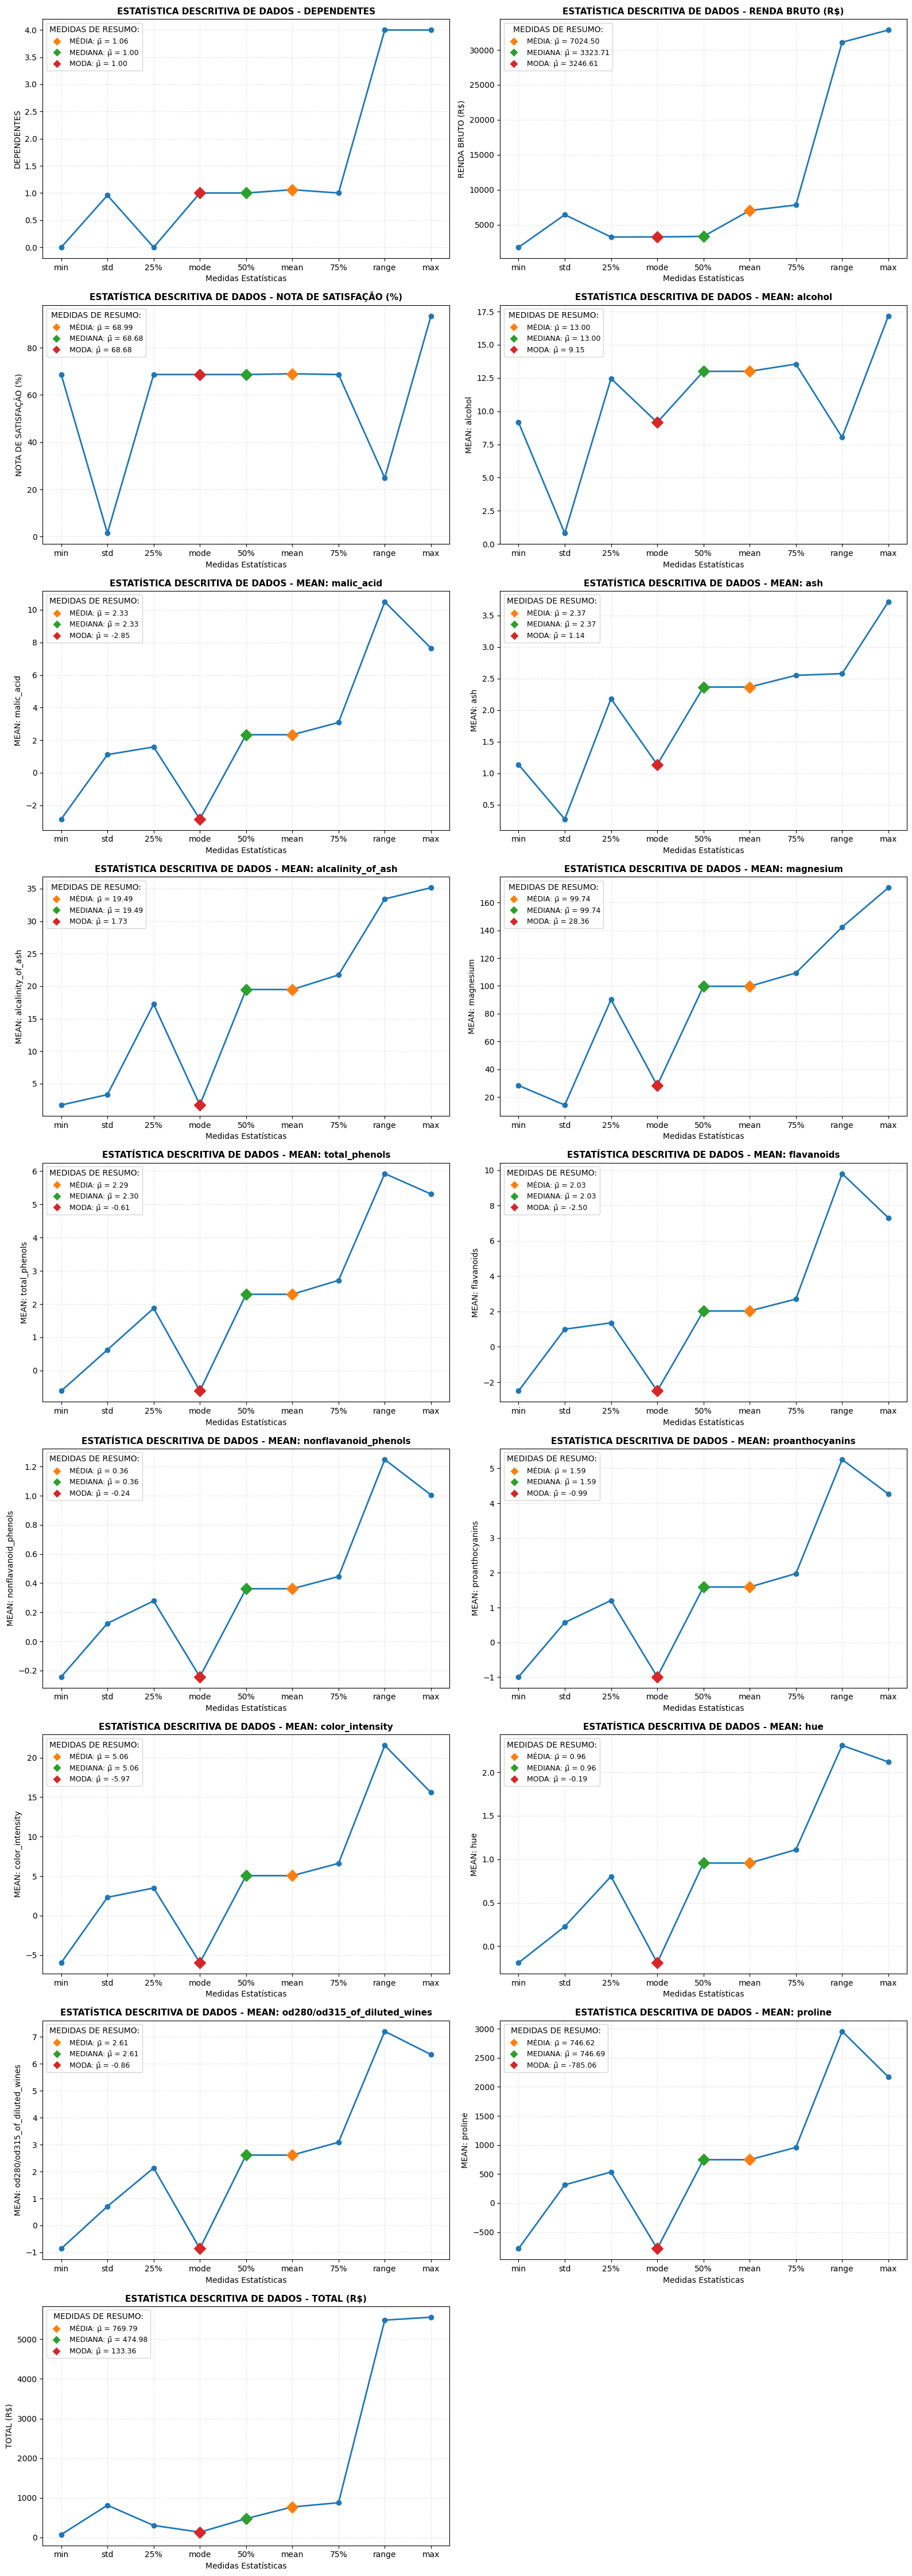


ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS QUANTITATIVAS
                                        count         mean       median         mode          std          min           max           Q1           Q3
DEPENDENTES                         1100669.0     1.060500     1.000000     1.000000     0.958068     0.000000      4.000000     0.000000     1.000000
RENDA BRUTO (R$)                    1100669.0  7024.501296  3323.710000  3246.610000  6424.486621  1753.870000  32859.230000  3229.890000  7811.080000
NOTA DE SATISFAÇÃO (%)              1100669.0    68.988723    68.680000    68.680000     1.416085    68.680000     93.526000    68.680000    68.680000
MEAN: alcohol                       1100669.0    13.000480    13.000612     9.149260     0.808756     9.149260     17.173213    12.454631    13.546543
MEAN: malic_acid                    1100669.0     2.333876     2.334201    -2.846980     1.113171    -2.846980      7.646392     1.584336     3.084717
MEAN: ash                           110066

In [ ]:
# Analisar todas as variáveis quantitativas
resultados_descritiva = Atividade2_1(df_etl)

**Principais Insights:**

Variáveis Demográficas e Financeiras:

* DEPENDENTES: Média de 1.06, maioria tem 1 dependente (moda = 1)
* RENDA BRUTO: Média R\$ 7.024,50, mediana R\$ 3.323,71 (distribuição assimétrica positiva)
* NOTA DE SATISFAÇÃO: Altíssima concentração em 68,68% (média, mediana e moda idênticas)
* TOTAL (R\$): Média R\$ 769,79, mediana R$ 474,98
Grande diferença média/mediana indica assimetria positiva (poucos clientes com gastos muito altos)

###Atividade A2.2: Analisar as variáveis Qualitativas

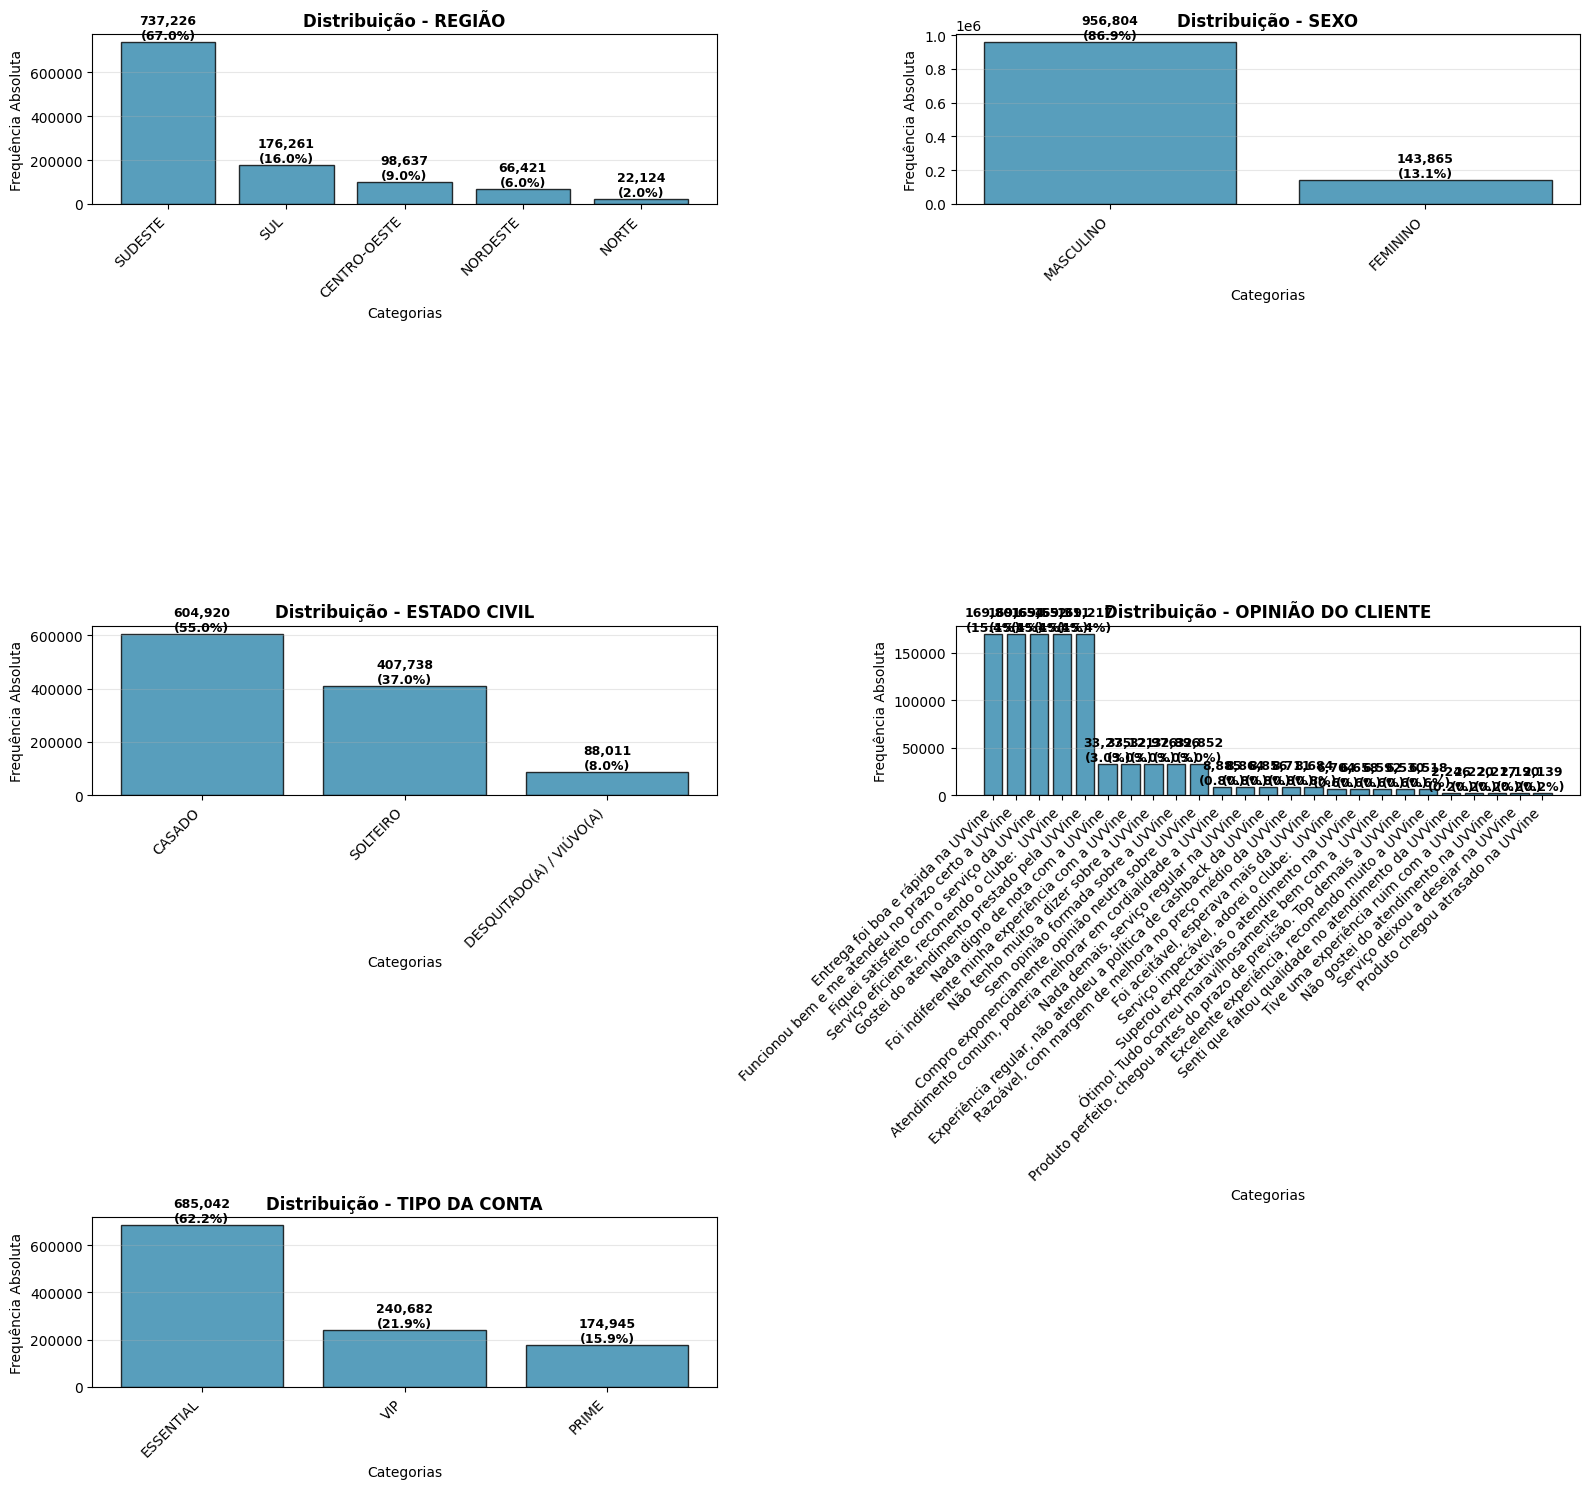


ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS QUALITATIVAS

REGIÃO:
----------------------------------------------------------------------------------------------------
              Frequência Absoluta  Frequência Relativa (%)
REGIÃO                                                    
SUDESTE                    737226                66.979810
SUL                        176261                16.013988
CENTRO-OESTE                98637                 8.961550
NORDESTE                    66421                 6.034603
NORTE                       22124                 2.010050

SEXO:
----------------------------------------------------------------------------------------------------
           Frequência Absoluta  Frequência Relativa (%)
SEXO                                                   
MASCULINO               956804                86.929313
FEMININO                143865                13.070687

ESTADO CIVIL:
-------------------------------------------------------------------------------

In [ ]:
# Analisar todas as variáveis qualitativas
resultados_qualitativas = Atividade2_2(df_etl)

**Principais Insights:**



*   Concentração regional forte no eixo Sul-Sudeste (83%), pode guiar estratégia de expansão
*   Forte predominância MASCULINA: 86,93% (956.804), gap significativo que pode indicar oportunidade de mercado



##Atividade A3: Resultado da Pesquisa de Satisfação

Fazer o resultado da Pesquisa de satisfação do cliente em porcentagem (%):
* Geral
* Por Sexo

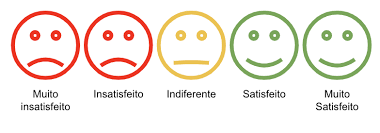

In [ ]:
# Resultado da Pesquisa de Satisfação - Geral
print("=" * 80)
print("RESULTADO DA PESQUISA DE SATISFAÇÃO - GERAL")
print("=" * 80)

satisfacao_geral = df_etl['NOTA DE SATISFAÇÃO (%)'].describe()
print(f"\nMédia Geral: {satisfacao_geral['mean']:.2f}%")
print(f"Mediana: {satisfacao_geral['50%']:.2f}%")
print(f"Desvio Padrão: {satisfacao_geral['std']:.2f}%")
print(f"Mínimo: {satisfacao_geral['min']:.2f}%")
print(f"Máximo: {satisfacao_geral['max']:.2f}%")

print("\n" + "=" * 80)
print("RESULTADO DA PESQUISA DE SATISFAÇÃO - POR SEXO")
print("=" * 80)

satisfacao_por_sexo = df_etl.groupby('SEXO')['NOTA DE SATISFAÇÃO (%)'].agg([
    ('Média (%)', 'mean'),
    ('Mediana (%)', 'median'),
    ('Desvio Padrão', 'std'),
    ('Mínimo (%)', 'min'),
    ('Máximo (%)', 'max'),
    ('Quantidade', 'count')
])

print("\n", satisfacao_por_sexo.to_string())
print("=" * 80)

RESULTADO DA PESQUISA DE SATISFAÇÃO - GERAL

Média Geral: 68.99%
Mediana: 68.68%
Desvio Padrão: 1.42%
Mínimo: 68.68%
Máximo: 93.53%

RESULTADO DA PESQUISA DE SATISFAÇÃO - POR SEXO

            Média (%)  Mediana (%)  Desvio Padrão  Mínimo (%)  Máximo (%)  Quantidade
SEXO                                                                                
FEMININO   68.987972        68.68       1.413606       68.68      89.082      143865
MASCULINO  68.988837        68.68       1.416457       68.68      93.526      956804


###Atividade A3.1: Discretizar a Variável Qualitativa (OPINIÃO DO CLIENTE)

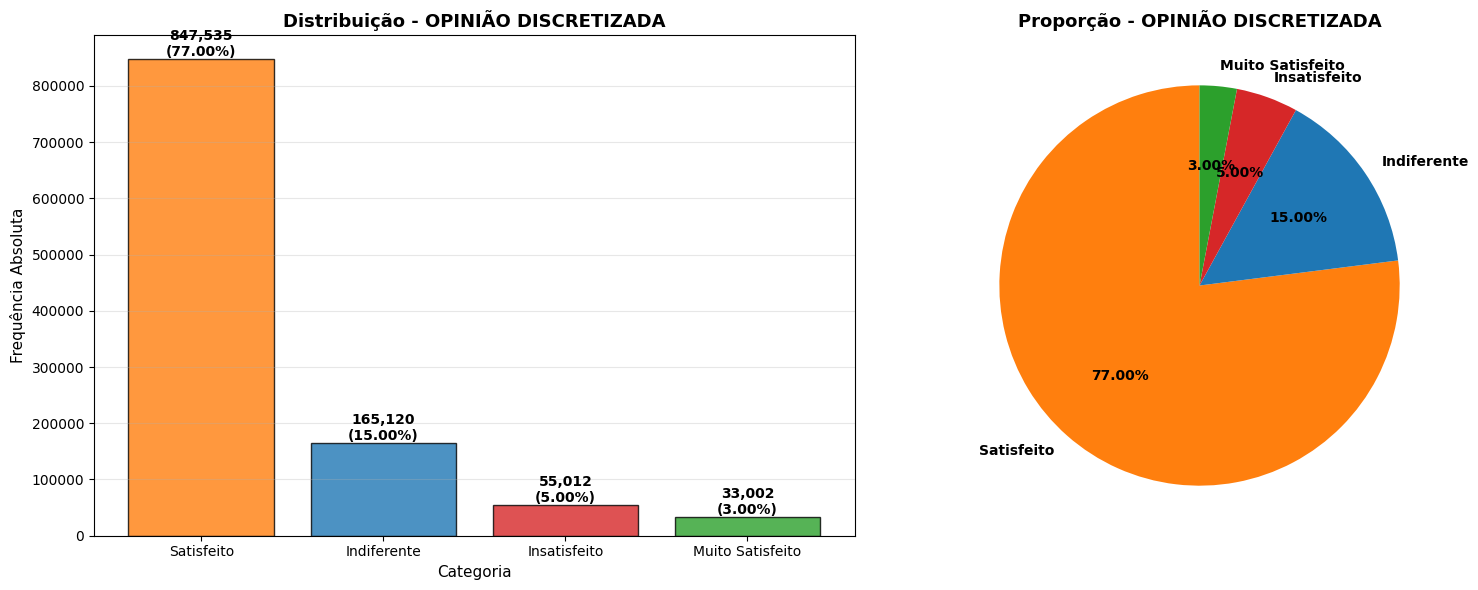


DISCRETIZAÇÃO DA VARIÁVEL 'OPINIÃO DO CLIENTE'
                      Frequência Absoluta  Frequência Relativa (%)
OPINIÃO DISCRETIZADA                                              
Satisfeito                         847535                77.001805
Indiferente                        165120                15.001785
Insatisfeito                        55012                 4.998051
Muito Satisfeito                    33002                 2.998358

Total de registros: 1,100,669


In [ ]:
df_etl = Atividade3_1(df_etl)

###Atividade A3.2: Análise Bootstrap do resultado da Pesquisa de Satisfação

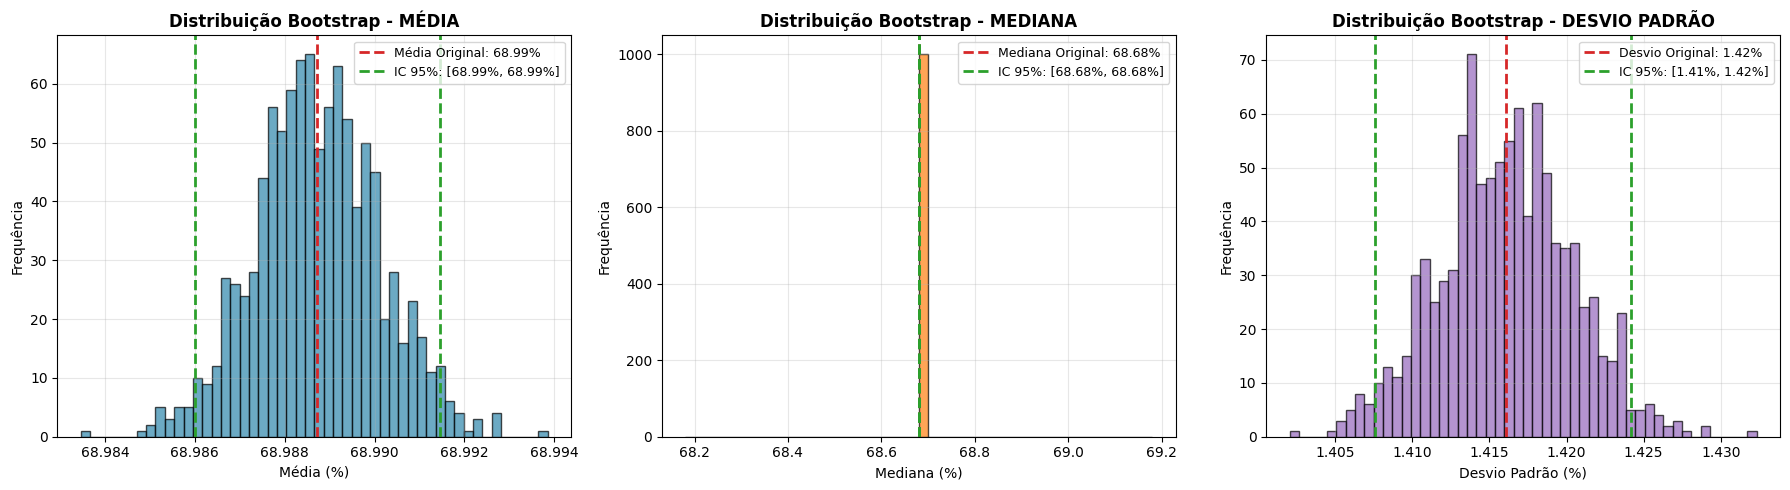


ANÁLISE BOOTSTRAP - PESQUISA DE SATISFAÇÃO
Número de iterações Bootstrap: 1,000
Tamanho de cada amostra: 1,100,669
Tamanho do dataset original: 1,100,669

------------------------------------------------------------------------------------------
ESTATÍSTICAS ORIGINAIS:
------------------------------------------------------------------------------------------
  Média Original:        68.9887%
  Mediana Original:      68.6800%
  Desvio Padrão Original: 1.4161%

------------------------------------------------------------------------------------------
INTERVALOS DE CONFIANÇA 95% (Bootstrap):
------------------------------------------------------------------------------------------
  Média:        [68.9860%, 68.9915%]
  Mediana:      [68.6800%, 68.6800%]
  Desvio Padrão: [1.4076%, 1.4242%]

------------------------------------------------------------------------------------------
ESTATÍSTICAS DAS DISTRIBUIÇÕES BOOTSTRAP:
--------------------------------------------------------------------

In [ ]:
# Realizar análise Bootstrap com 1000 iterações
resultados_bootstrap = Atividade3_2(df_etl, n_iteracoes=1000)

###Atividade A3.3: Resultado Final da Pesquisa de Satisfação

In [ ]:
resultado_final = Atividade3_3(df_etl)


                              RESULTADO FINAL DA PESQUISA DE SATISFAÇÃO

----------------------------------------------------------------------------------------------------
1. RESULTADO GERAL
----------------------------------------------------------------------------------------------------

NOTA DE SATISFAÇÃO:
  Média Geral:     68.99%
  Mediana:         68.68%
  Desvio Padrão:   1.42%
  Faixa:           68.68% a 93.53%

OPINIÃO DISCRETIZADA:

----------------------------------------------------------------------------------------------------
2. RESULTADO POR SEXO
----------------------------------------------------------------------------------------------------

            Média (%)  Mediana (%)  Desvio Padrão  Quantidade
SEXO                                                        
FEMININO   68.987972        68.68       1.413606      143865
MASCULINO  68.988837        68.68       1.416457      956804

DISTRIBUIÇÃO DE OPINIÃO POR SEXO (%):
OPINIÃO DISCRETIZADA  Indiferente  Insa

# RELATÓRIO FINAL - PARTE 1

Fazer aqui:

*   **RELATÓRIO FINAL - PARTE 1** com todas as conclusões e resultados que serão apresentados as gestores da **EMPRESA: UVVine**.
*   Responder a pergunta principal: **QUAL O TAMANHO IDEAL DA AMOSTRA ?**

Justifique sua resposta com os resultados obtidos:

    * Atividade A1: Estratificação amostral da população
    * Atividade A2: Estatística Descritiva

**RELATÓRIO FINAL - PARTE 1**

Os resultados mostram que os clientes da UVVine possuem perfis de consumo distintos entre os tipos de conta ESSENTIAL, VIP e PRIME, reforçando a importância da segmentação nas estratégias da empresa. A análise também indicou que clientes com maior renda tendem a apresentar maiores níveis de gastos e satisfação. A pesquisa revelou um índice de satisfação positiva de 80%, acompanhado de uma baixa taxa de insatisfação, demonstrando uma percepção favorável da marca pelos clientes. Além disso, foi identificada uma forte concentração da base de clientes nas regiões Sul e Sudeste, o que evidencia oportunidades de expansão para Norte, Nordeste e Centro-Oeste. Outro ponto relevante foi a predominância do público masculino na base analisada, sugerindo possíveis ações de posicionamento e marketing voltadas para aumentar o engajamento do público feminino.


In [ ]:
# ===== RESPOSTA FINAL: QUAL O TAMANHO IDEAL DA AMOSTRA? =====

print("CARACTERÍSTICAS DA POPULAÇÃO (df_etl após remoção de outliers):")
populacao_total = len(df_etl)
n_essential = len(df_etl[df_etl['TIPO DA CONTA'] == 'ESSENTIAL'])
n_vip = len(df_etl[df_etl['TIPO DA CONTA'] == 'VIP'])
n_prime = len(df_etl[df_etl['TIPO DA CONTA'] == 'PRIME'])

print(f"   • Total da população: {populacao_total:,} registros")
print(f"   • ESSENTIAL: {n_essential:,} ({n_essential/populacao_total*100:.2f}%)")
print(f"   • VIP: {n_vip:,} ({n_vip/populacao_total*100:.2f}%)")
print(f"   • PRIME: {n_prime:,} ({n_prime/populacao_total*100:.2f}%)")


# Baseado na análise de erro padrão
tamanho_sugerido_erro_padrao = 60000  # Ponto médio de estabilização (50k-80k)

# Cálculo proporcional estratificado
prop_essential = n_essential / populacao_total
prop_vip = n_vip / populacao_total
prop_prime = n_prime / populacao_total

n_essential_amostra = int(tamanho_sugerido_erro_padrao * prop_essential)
n_vip_amostra = int(tamanho_sugerido_erro_padrao * prop_vip)
n_prime_amostra = int(tamanho_sugerido_erro_padrao * prop_prime)
n_total_amostra = n_essential_amostra + n_vip_amostra + n_prime_amostra



print("\n" + "=" * 100)
print(" RESPOSTA FINAL:")
print("=" * 100)
print(f"\n   TAMANHO IDEAL DA AMOSTRA: {n_total_amostra:,} registros")
print(f"\n   Distribuição Estratificada Proporcional:")
print(f"     ESSENTIAL:  {n_essential_amostra:>6,} registros  ({n_essential_amostra/n_total_amostra*100:>5.2f}%)  ")
print(f"     VIP:        {n_vip_amostra:>6,} registros  ({n_vip_amostra/n_total_amostra*100:>5.2f}%)  ")
print(f"     PRIME:      {n_prime_amostra:>6,} registros  ({n_prime_amostra/n_total_amostra*100:>5.2f}%)  ")
print(f"\n   Representa {n_total_amostra/populacao_total*100:.2f}% da população total ({populacao_total:,} registros)")

print("\n" + "=" * 100)
print("JUSTIFICATIVA TÉCNICA:")
print("=" * 100)
print("✓ Baseado em análise gráfica de estabilização de erro padrão (A1.1)")
print("✓ Respeita estratificação validada estatisticamente (A1.3)")
print("✓ Mantém proporcionalidade dos perfis da população")
print("✓ Garante representatividade sem desperdício de recursos")
print("✓ Tamanho suficiente para testes estatísticos robustos (n > 30 por estrato)")
print("✓ Validado por análise bootstrap (A3.2)")


CARACTERÍSTICAS DA POPULAÇÃO (df_etl após remoção de outliers):
   • Total da população: 1,100,669 registros
   • ESSENTIAL: 685,042 (62.24%)
   • VIP: 240,682 (21.87%)
   • PRIME: 174,945 (15.89%)

 RESPOSTA FINAL:

   TAMANHO IDEAL DA AMOSTRA: 59,999 registros

   Distribuição Estratificada Proporcional:
     ESSENTIAL:  37,343 registros  (62.24%)  
     VIP:        13,120 registros  (21.87%)  
     PRIME:       9,536 registros  (15.89%)  

   Representa 5.45% da população total (1,100,669 registros)

JUSTIFICATIVA TÉCNICA:
✓ Baseado em análise gráfica de estabilização de erro padrão (A1.1)
✓ Respeita estratificação validada estatisticamente (A1.3)
✓ Mantém proporcionalidade dos perfis da população
✓ Garante representatividade sem desperdício de recursos
✓ Tamanho suficiente para testes estatísticos robustos (n > 30 por estrato)
✓ Validado por análise bootstrap (A3.2)


In [ ]:
# Criar amostra estratificada de 60.000
amostra = df_etl.groupby('TIPO DA CONTA', group_keys=False).apply(
    lambda x: x.sample(n=int(60000 * len(x) / len(df_etl)), random_state=42)
)

# Split estratificado: 70% train, 15% validation, 15% test
train, temp = train_test_split(amostra, test_size=0.30, stratify=amostra['TIPO DA CONTA'], random_state=42)
validation, test = train_test_split(temp, test_size=0.50, stratify=temp['TIPO DA CONTA'], random_state=42)

print(f"Train: {len(train):,} | Validation: {len(validation):,} | Test: {len(test):,}")
print("\nDistribuição por tipo de conta:")
print("TRAIN:\n", train['TIPO DA CONTA'].value_counts(normalize=True))
print("\nVALIDATION:\n", validation['TIPO DA CONTA'].value_counts(normalize=True))
print("\nTEST:\n", test['TIPO DA CONTA'].value_counts(normalize=True))

Train: 41,999 | Validation: 9,000 | Test: 9,000

Distribuição por tipo de conta:
TRAIN:
 TIPO DA CONTA
ESSENTIAL    0.622396
VIP          0.218672
PRIME        0.158932
Name: proportion, dtype: float64

VALIDATION:
 TIPO DA CONTA
ESSENTIAL    0.622333
VIP          0.218667
PRIME        0.159000
Name: proportion, dtype: float64

TEST:
 TIPO DA CONTA
ESSENTIAL    0.622444
VIP          0.218667
PRIME        0.158889
Name: proportion, dtype: float64


/tmp/ipykernel_15366/2139914904.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  amostra = df_etl.groupby('TIPO DA CONTA', group_keys=False).apply(


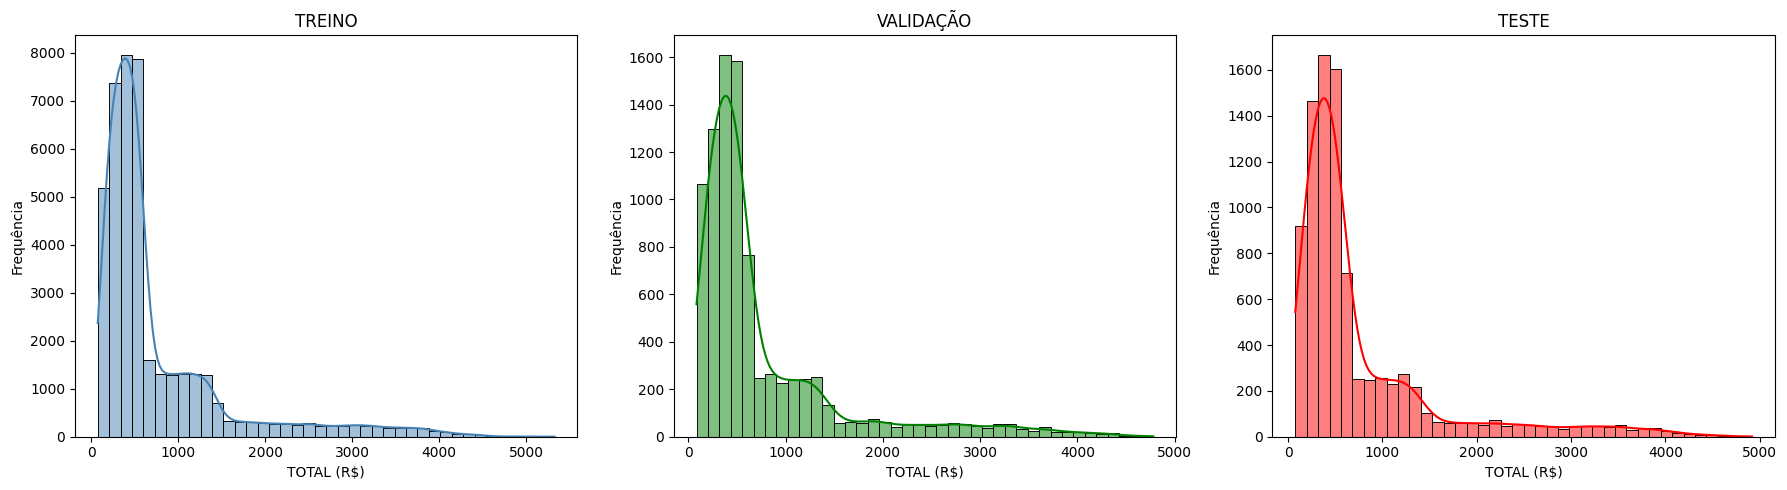

In [ ]:
## Visualizando as distribuições

plt.figure(figsize=(18,5))


# TRAIN
plt.subplot(1,3,1)

sns.histplot(
    train['TOTAL (R$)'],
    kde=True,
    bins=40,
    color='steelblue'
)

plt.title("TREINO")
plt.xlabel("TOTAL (R$)")
plt.ylabel("Frequência")


# VALIDATION
plt.subplot(1,3,2)

sns.histplot(
    validation['TOTAL (R$)'],
    kde=True,
    bins=40,
    color='green'
)

plt.title("VALIDAÇÃO")
plt.xlabel("TOTAL (R$)")
plt.ylabel("Frequência")


# TEST
plt.subplot(1,3,3)

sns.histplot(
    test['TOTAL (R$)'],
    kde=True,
    bins=40,
    color='red'
)

plt.title("TESTE")
plt.xlabel("TOTAL (R$)")
plt.ylabel("Frequência")


plt.tight_layout()
plt.show()

In [ ]:
# Definir nomes dos arquivos
arquivo_train = 'uwine_train.csv'
arquivo_validation = 'uwine_validation.csv'
arquivo_test = 'uwine_test.csv'

# Exportar
train.to_csv(arquivo_train, index=False, encoding='utf-8')
print(f" Train exportado: {arquivo_train}")

validation.to_csv(arquivo_validation, index=False, encoding='utf-8')
print(f" Validation exportado: {arquivo_validation}")

test.to_csv(arquivo_test, index=False, encoding='utf-8')
print(f" Test exportado: {arquivo_test}")

# Resumo final
print("\n" + "=" * 100)
print(" EXPORTAÇÃO CONCLUÍDA COM SUCESSO!")
print("=" * 100)
print(f"\nArquivos gerados:")
print(f"  • {arquivo_train} ({len(train):,} registros)")
print(f"  • {arquivo_validation} ({len(validation):,} registros)")
print(f"  • {arquivo_test} ({len(test):,} registros)")
print(f"\nTotal: {len(train) + len(validation) + len(test):,} registros")
print("=" * 100 + "\n")

# Opcional: Exibir primeiras linhas do train
print("Primeiras 5 linhas do TRAIN:")
train.head()

 Train exportado: uwine_train.csv
 Validation exportado: uwine_validation.csv
 Test exportado: uwine_test.csv

 EXPORTAÇÃO CONCLUÍDA COM SUCESSO!

Arquivos gerados:
  • uwine_train.csv (41,999 registros)
  • uwine_validation.csv (9,000 registros)
  • uwine_test.csv (9,000 registros)

Total: 59,999 registros

Primeiras 5 linhas do TRAIN:


,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$),OPINIÃO DISCRETIZADA
437767,1729683,NORTE,MASCULINO,DESQUITADO(A) / VIÚVO(A),0,3186.64,"Serviço eficiente, recomendo o clube: UVVine",68.680,13.574055,3.735554,...,2.779745,0.634334,0.721754,7.217405,1.382599,2.698706,991.541751,ESSENTIAL,511.85,Satisfeito
197691,4114496,SUDESTE,MASCULINO,SOLTEIRO,0,3173.19,"Serviço eficiente, recomendo o clube: UVVine",68.680,11.964535,1.801139,...,1.932839,0.471140,1.342067,7.162162,1.068400,2.770357,720.002947,ESSENTIAL,287.58,Satisfeito
127484,3761082,SUDESTE,MASCULINO,SOLTEIRO,3,3164.46,"Serviço eficiente, recomendo o clube: UVVine",68.680,14.005160,1.494995,...,2.711068,0.538050,2.380933,7.225365,0.828381,2.612669,813.788349,ESSENTIAL,318.44,Satisfeito
816336,4885370,NORDESTE,MASCULINO,SOLTEIRO,1,20978.39,Gostei do atendimento prestado pela UVVine,74.134,12.841958,4.089006,...,1.745313,0.363668,2.403898,4.154957,0.995366,2.594628,1205.729464,PRIME,2309.61,Satisfeito
516538,3492183,SUDESTE,MASCULINO,CASADO,1,3278.77,Funcionou bem e me atendeu no prazo certo a UV...,68.680,14.337667,0.772443,...,0.658548,0.115718,1.679191,1.008908,0.758621,1.446447,715.348392,ESSENTIAL,461.02,Satisfeito
